<a href="https://www.kaggle.com/code/lalit7881/student-performance-study-habits?scriptVersionId=336459381" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/harshadapatil31/student-performance-and-study-habits-dataset/student_performance_dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/harshadapatil31/student-performance-and-study-habits-dataset/student_performance_dataset.csv")

In [3]:
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [4]:
df.tail()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
995,996,Male,2.8,75.4,8.2,Masters,Yes,Yes,No,60.5,70.7,C
996,997,Male,6.7,88.4,7.1,NaN,No,Yes,No,82.2,99.5,A
997,998,Female,2.6,84.5,8.0,High School,Yes,Yes,Yes,65.2,79.2,C
998,999,Female,4.6,85.3,8.1,High School,No,No,Yes,52.2,82.2,B
999,1000,Male,3.9,77.4,6.1,Masters,Yes,No,No,45.4,70.4,C


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


In [6]:
df.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


In [7]:
df.isnull()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,True,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,True,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

student_id                      0
gender                          0
study_time_hours                0
attendance_percent              0
sleep_hours                     0
parental_education            102
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
final_exam_score                0
final_grade                     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

student_id                      int64
gender                         object
study_time_hours              float64
attendance_percent            float64
sleep_hours                   float64
parental_education             object
internet_access                object
extracurricular_activities     object
part_time_job                  object
previous_grade                float64
final_exam_score              float64
final_grade                    object
dtype: object

In [11]:
df.shape

(1000, 12)

In [12]:
df.columns

Index(['student_id', 'gender', 'study_time_hours', 'attendance_percent',
       'sleep_hours', 'parental_education', 'internet_access',
       'extracurricular_activities', 'part_time_job', 'previous_grade',
       'final_exam_score', 'final_grade'],
      dtype='object')

In [13]:
df.nunique()

student_id                    1000
gender                           2
study_time_hours                70
attendance_percent             327
sleep_hours                     65
parental_education               4
internet_access                  2
extracurricular_activities       2
part_time_job                    2
previous_grade                 434
final_exam_score               342
final_grade                      5
dtype: int64

In [14]:
import plotly.express as px

## EDA

In [15]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include='object').columns

print("Numerical Columns")
print(num_cols)

print("\nCategorical Columns")
print(cat_cols)

Numerical Columns
Index(['student_id', 'study_time_hours', 'attendance_percent', 'sleep_hours',
       'previous_grade', 'final_exam_score'],
      dtype='object')

Categorical Columns
Index(['gender', 'parental_education', 'internet_access',
       'extracurricular_activities', 'part_time_job', 'final_grade'],
      dtype='object')


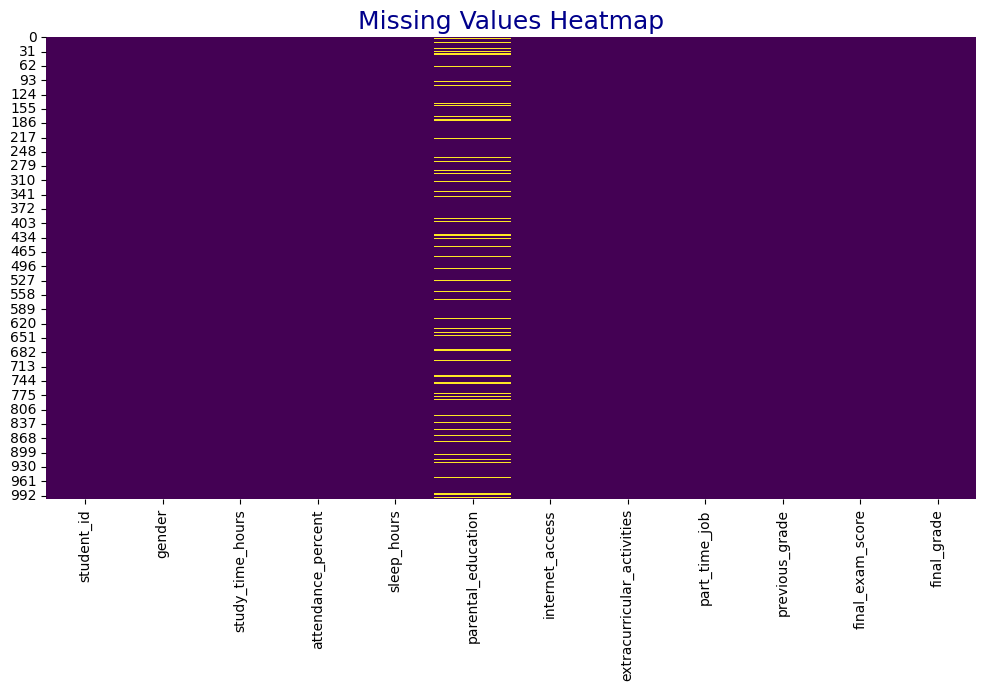

In [16]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(),
            cmap='viridis',
            cbar=False)

plt.title("Missing Values Heatmap",
          fontsize=18,
          color='darkblue')

plt.show()

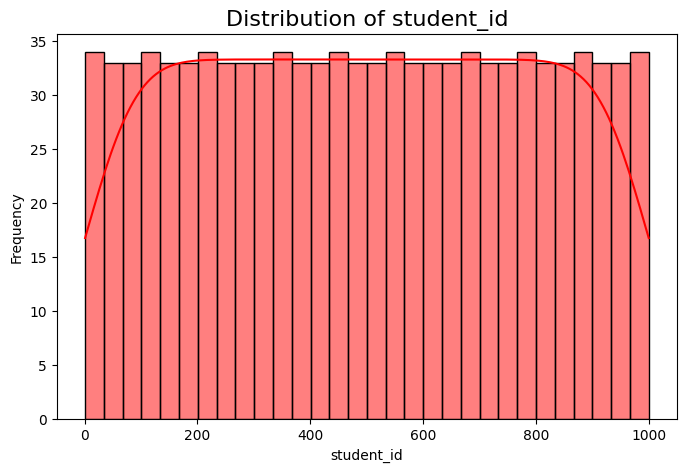

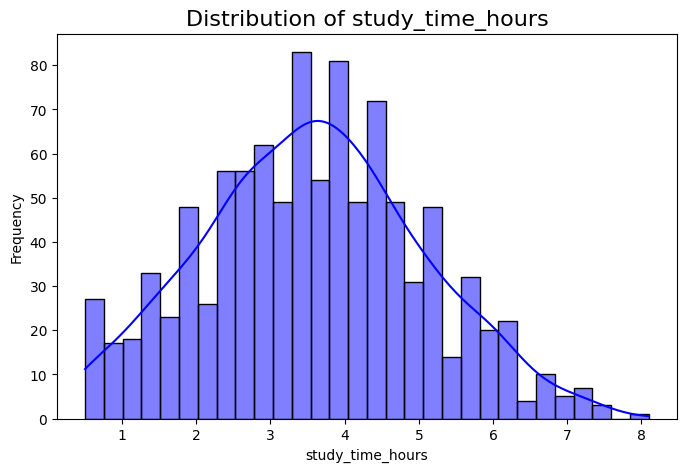

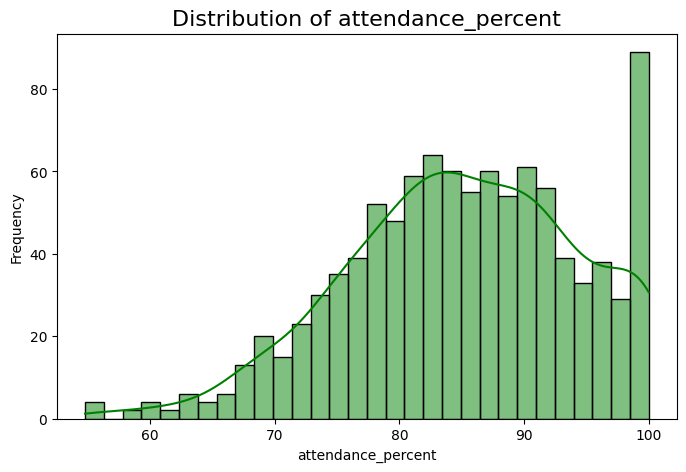

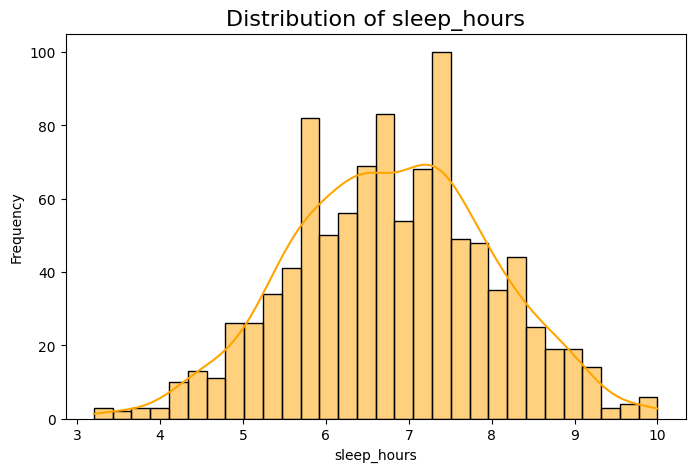

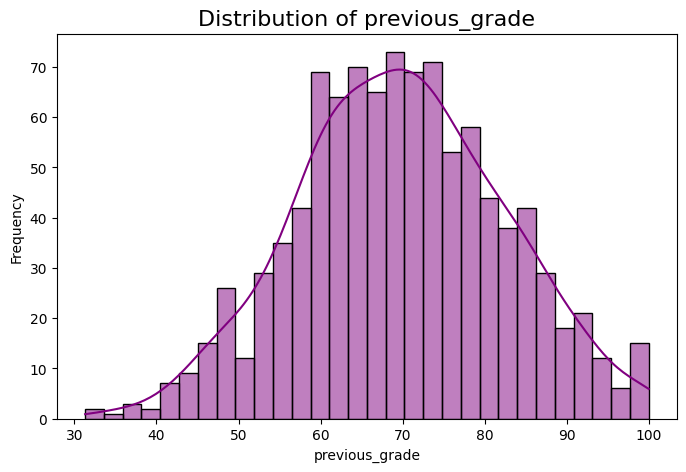

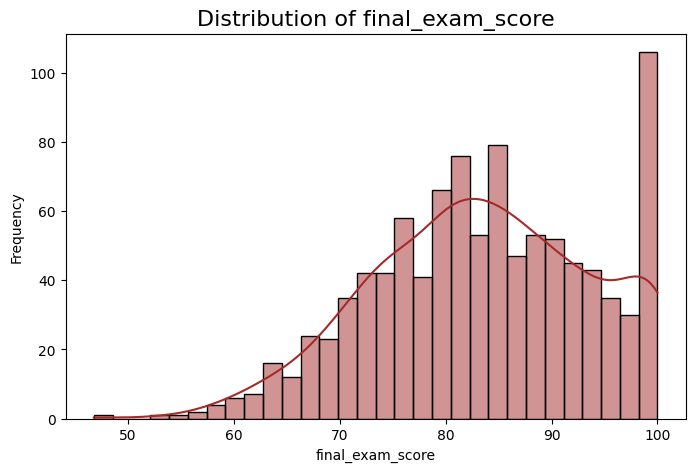

In [17]:
colors = ['red','blue','green','orange','purple','brown','cyan','magenta']

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,5))

    sns.histplot(df[col],
                 kde=True,
                 color=colors[i%len(colors)],
                 bins=30)

    plt.title(f"Distribution of {col}",
              fontsize=16)

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.show()

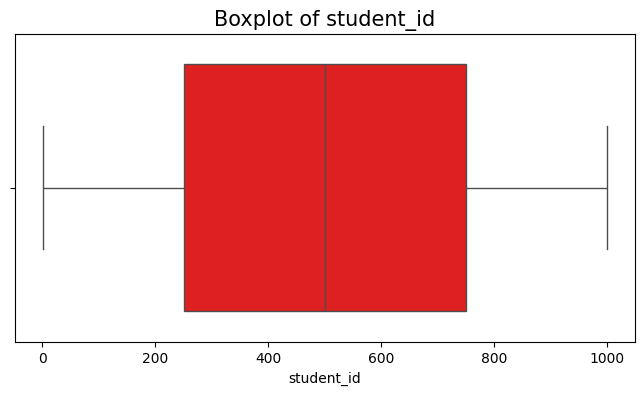

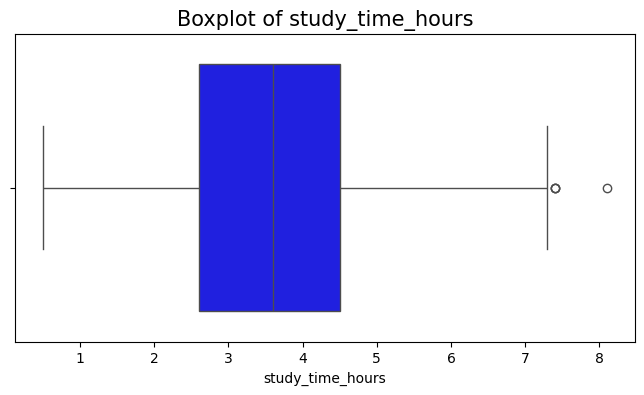

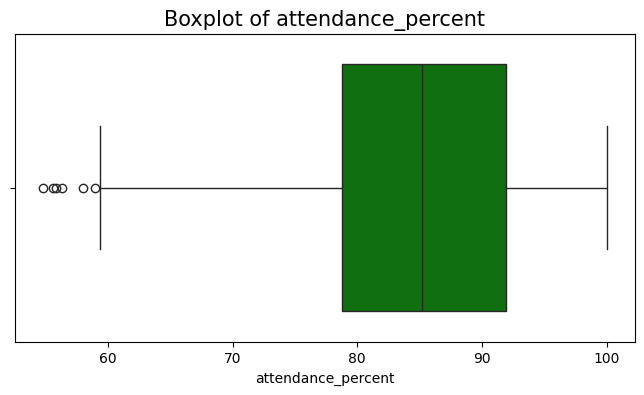

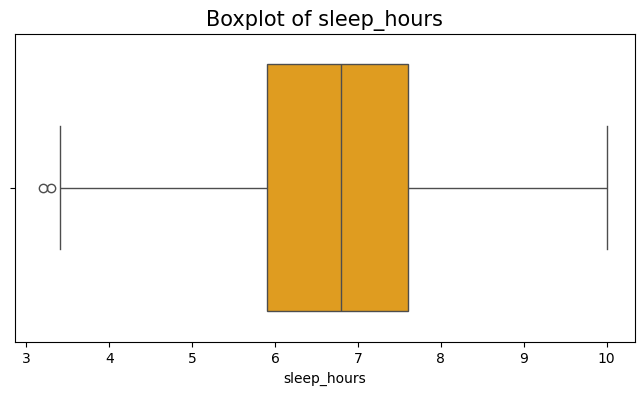

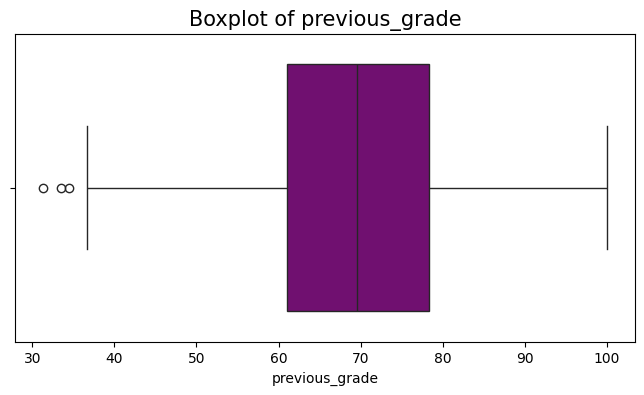

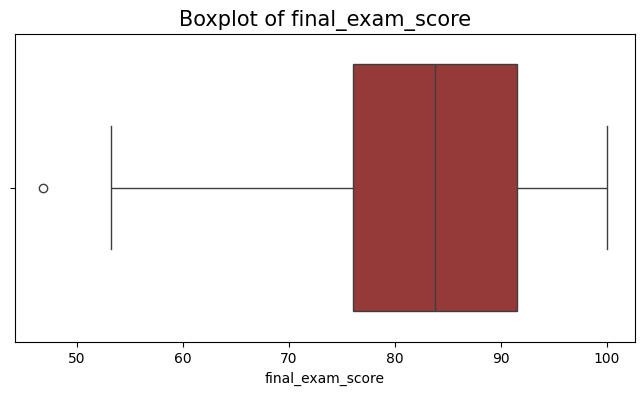

In [18]:
for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col],
                color=colors[i%len(colors)])

    plt.title(f"Boxplot of {col}",
              fontsize=15)

    plt.show()

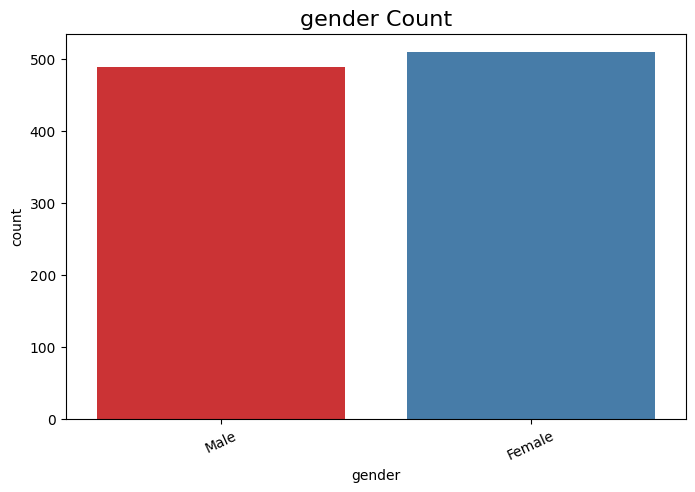

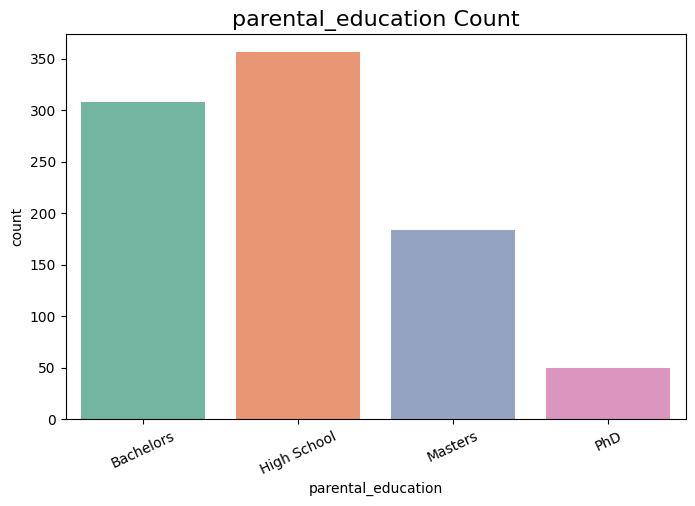

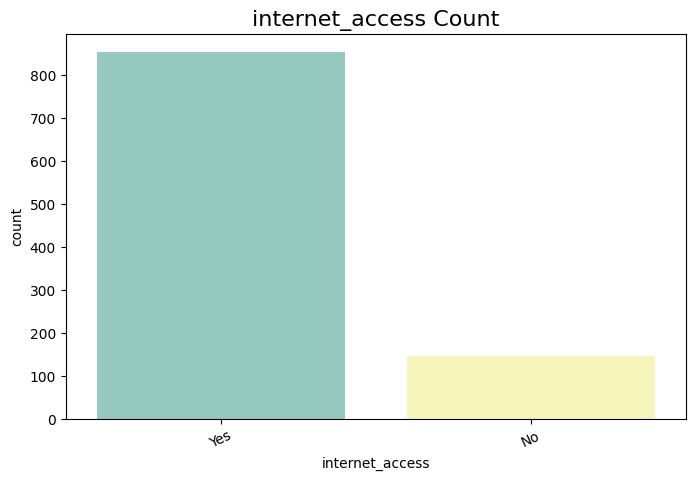

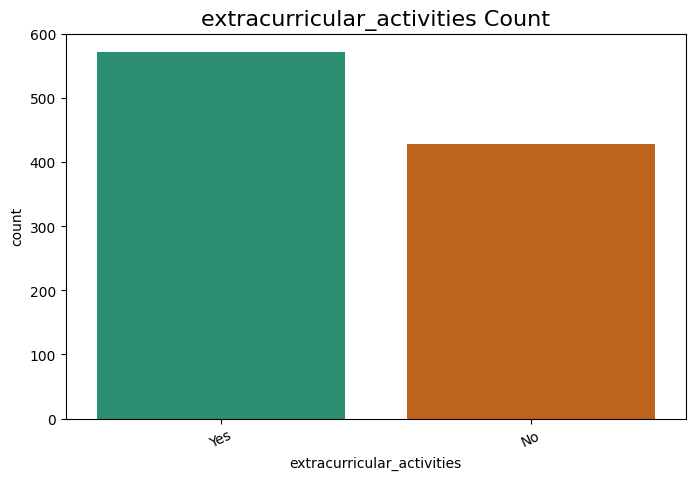

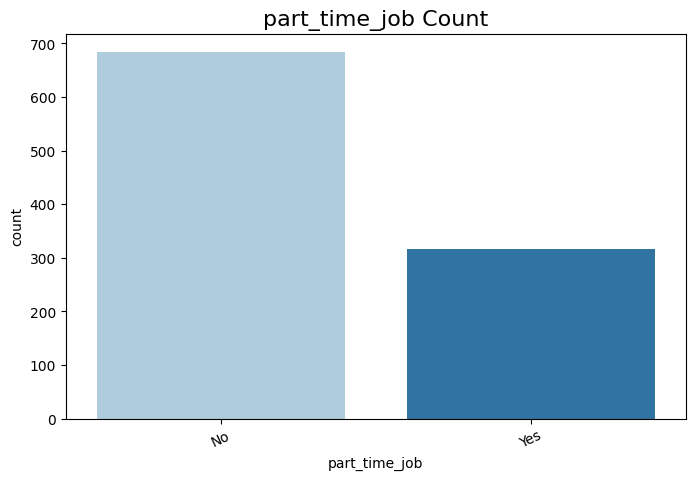

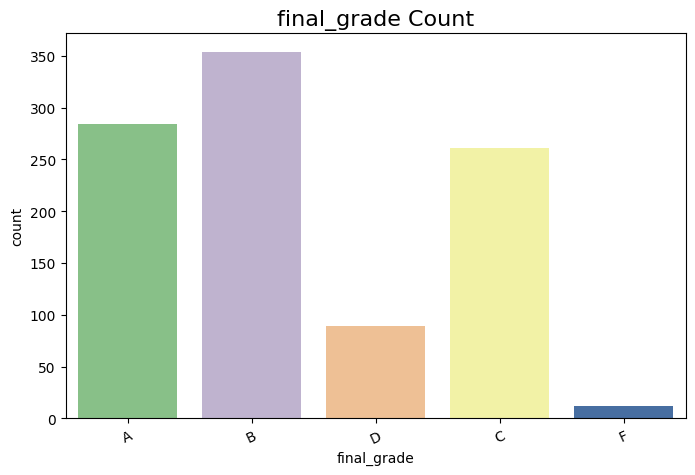

In [19]:
palette_list = [
    "Set1",
    "Set2",
    "Set3",
    "Dark2",
    "Paired",
    "Accent"
]

for i,col in enumerate(cat_cols):

    plt.figure(figsize=(8,5))

    sns.countplot(data=df,
                  x=col,
                  palette=palette_list[i%len(palette_list)])

    plt.title(f"{col} Count",
              fontsize=16)

    plt.xticks(rotation=25)

    plt.show()

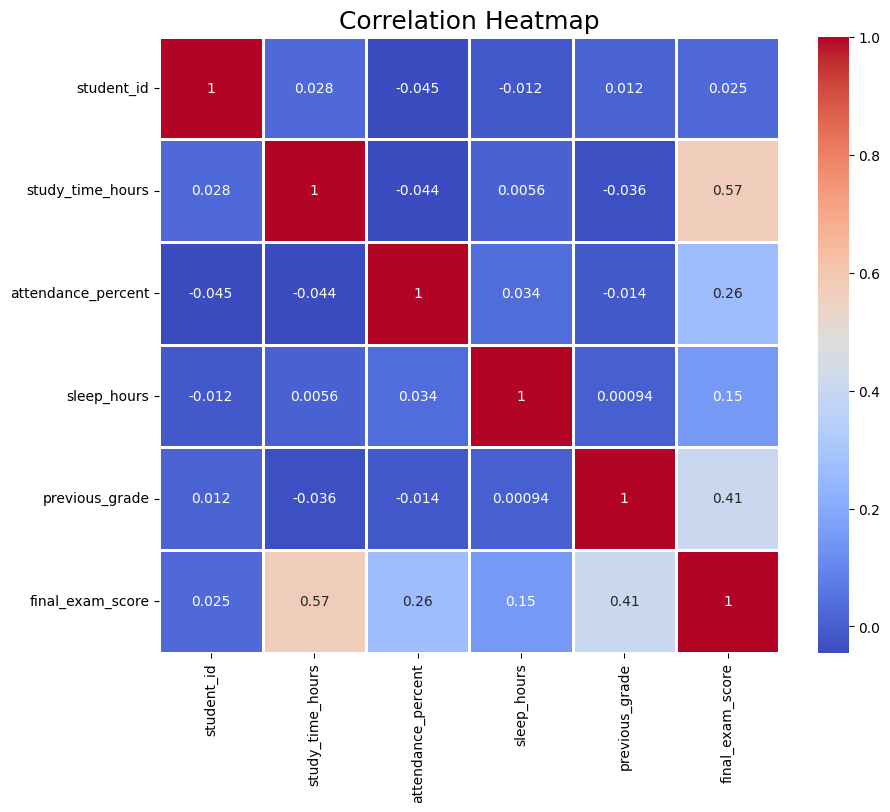

In [20]:
plt.figure(figsize=(10,8))

corr = df[num_cols].corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            linewidths=1)

plt.title("Correlation Heatmap",
          fontsize=18)

plt.show()

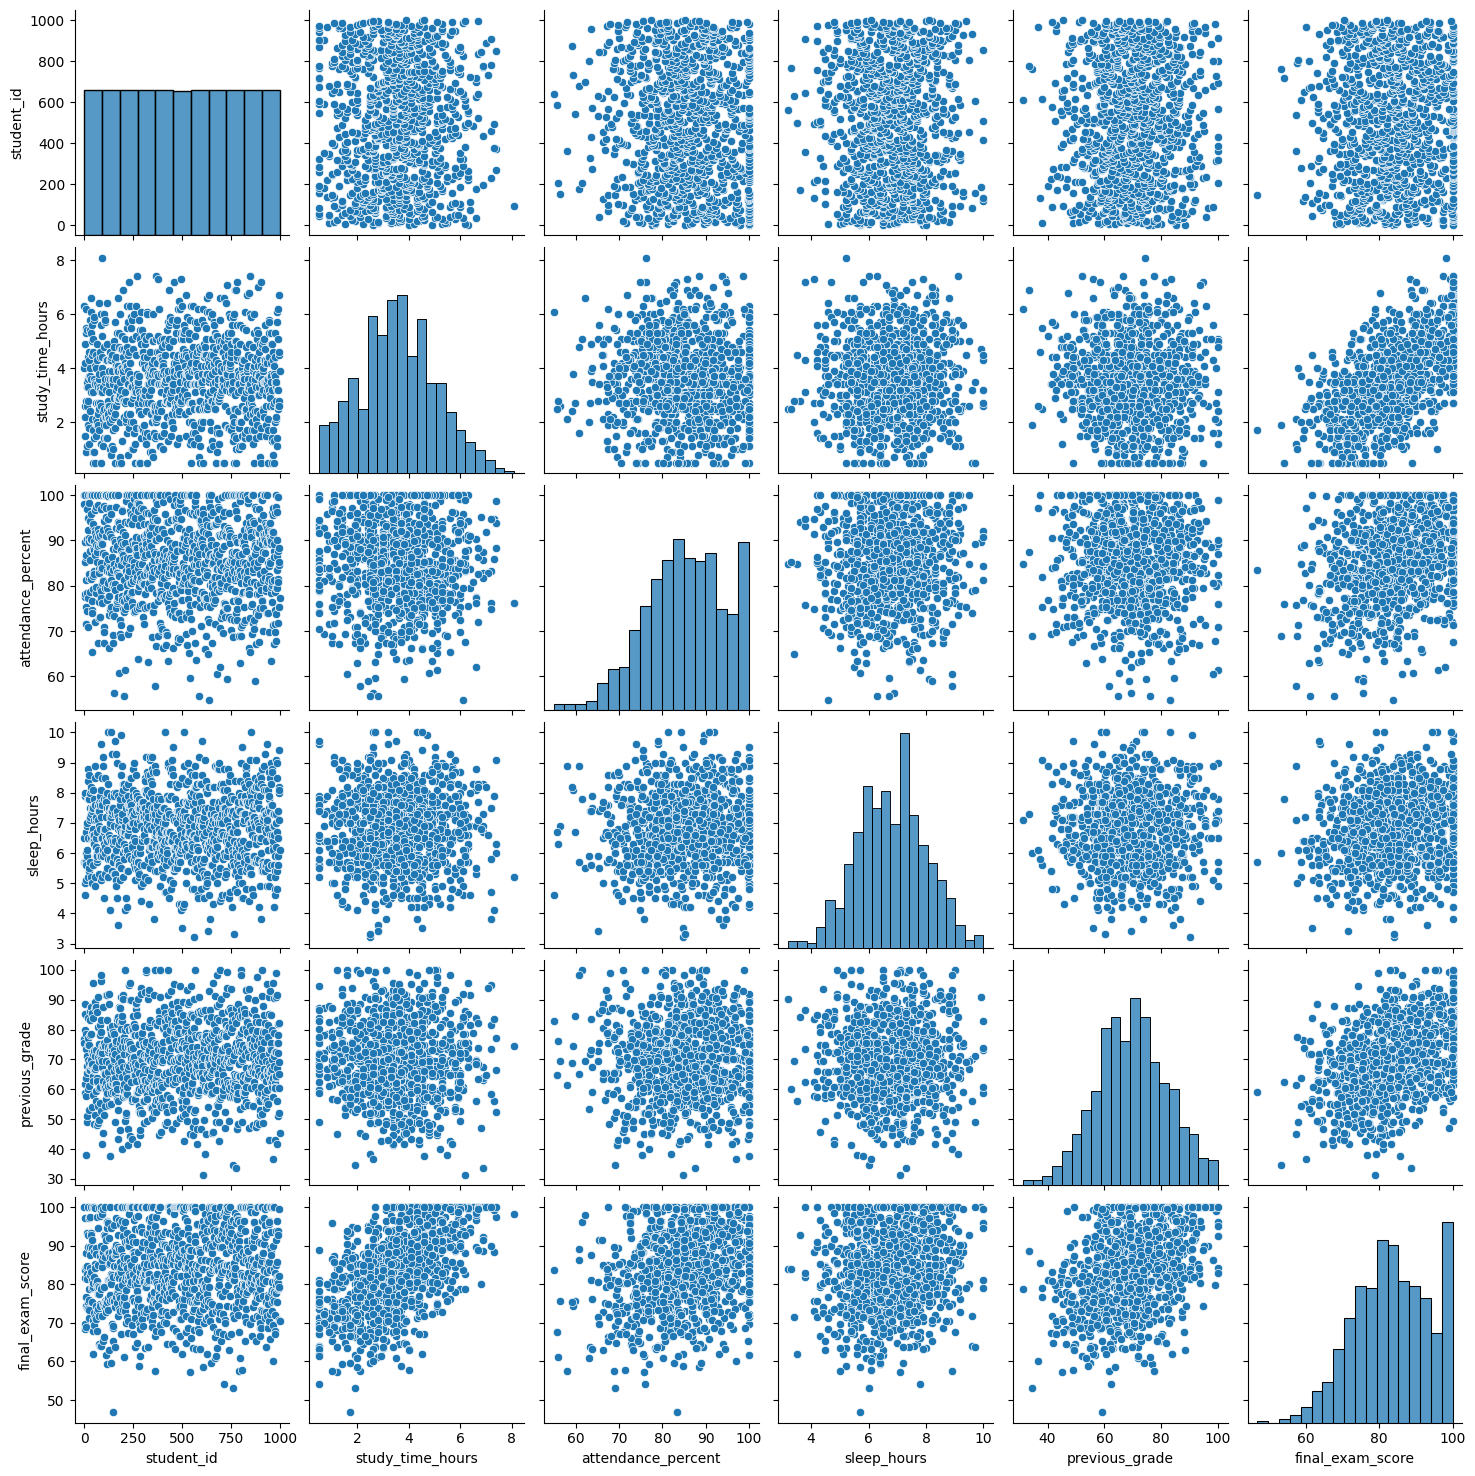

In [21]:
sns.pairplot(df[num_cols],
             palette='husl')

plt.show()

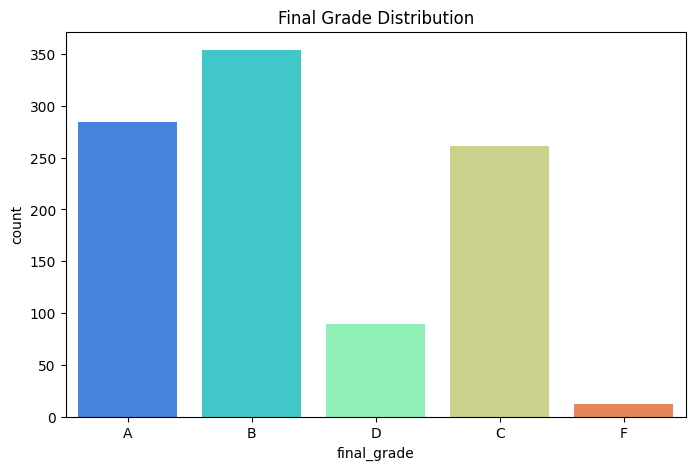

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x='final_grade',
              palette='rainbow')

plt.title("Final Grade Distribution")

plt.show()

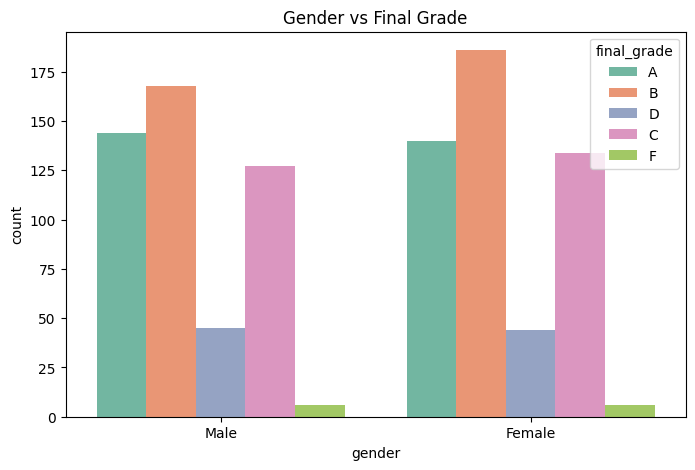

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x='gender',
              hue='final_grade',
              palette='Set2')

plt.title("Gender vs Final Grade")

plt.show()

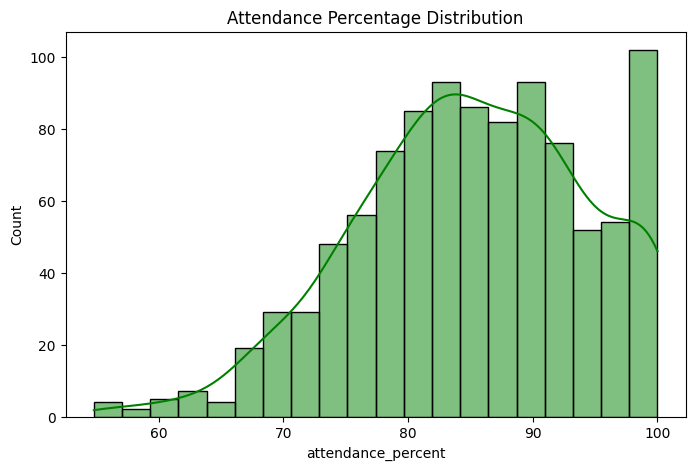

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df["attendance_percent"],
             color='green',
             kde=True,
             bins=20)

plt.title("Attendance Percentage Distribution")

plt.show()

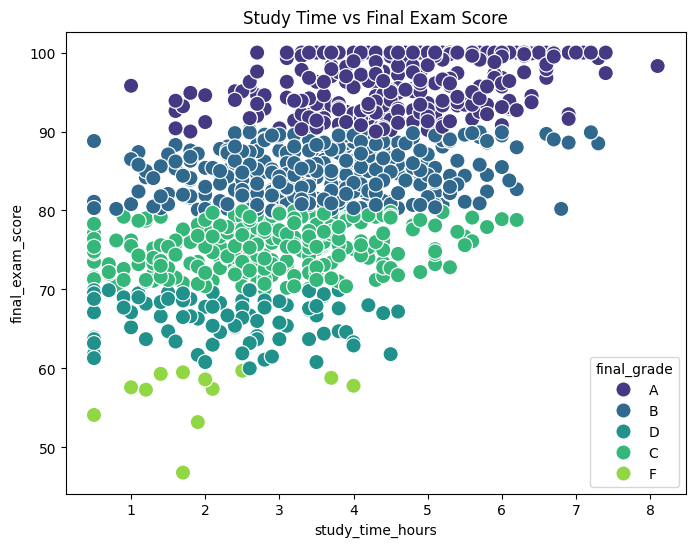

In [25]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df,
                x='study_time_hours',
                y='final_exam_score',
                hue='final_grade',
                palette='viridis',
                s=120)

plt.title("Study Time vs Final Exam Score")

plt.show()

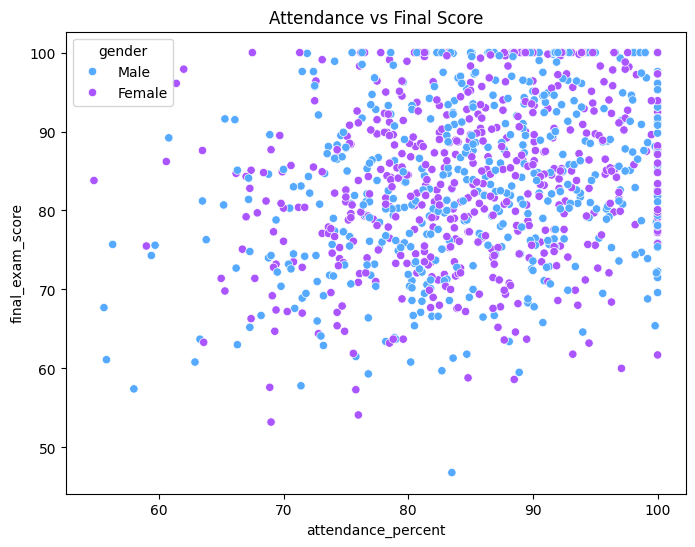

In [26]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df,
                x='attendance_percent',
                y='final_exam_score',
                hue='gender',
                palette='cool')

plt.title("Attendance vs Final Score")

plt.show()

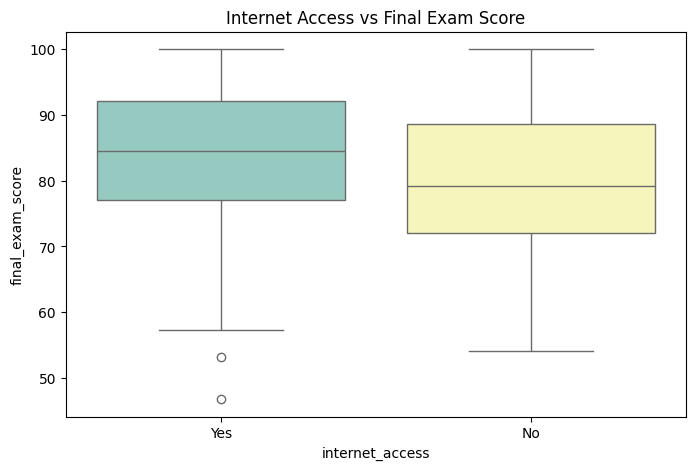

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x='internet_access',
            y='final_exam_score',
            palette='Set3')

plt.title("Internet Access vs Final Exam Score")

plt.show()

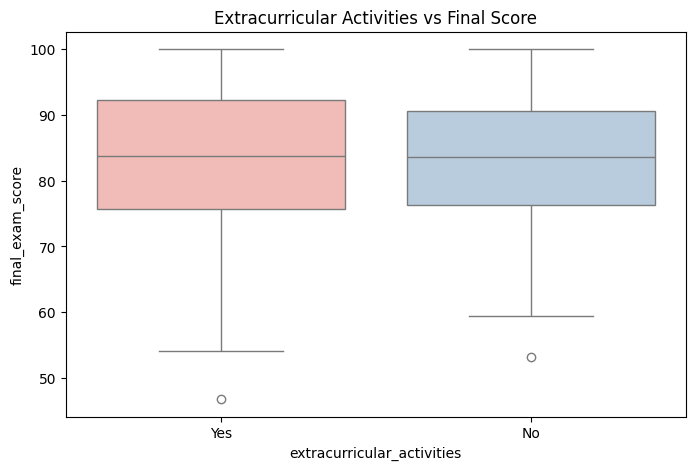

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x='extracurricular_activities',
            y='final_exam_score',
            palette='Pastel1')

plt.title("Extracurricular Activities vs Final Score")

plt.show()

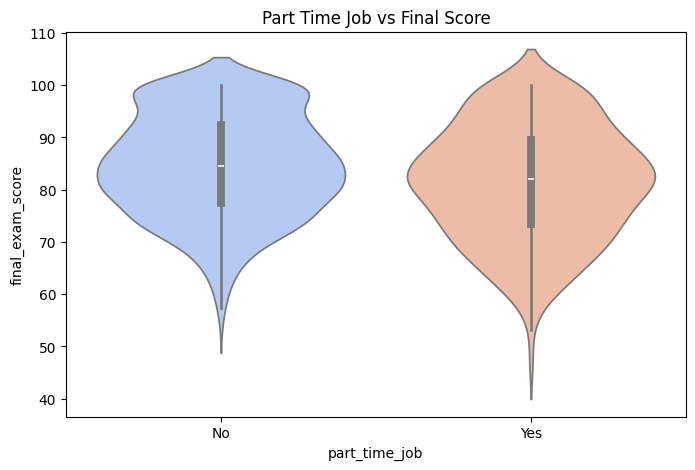

In [29]:
plt.figure(figsize=(8,5))

sns.violinplot(data=df,
               x='part_time_job',
               y='final_exam_score',
               palette='coolwarm')

plt.title("Part Time Job vs Final Score")

plt.show()

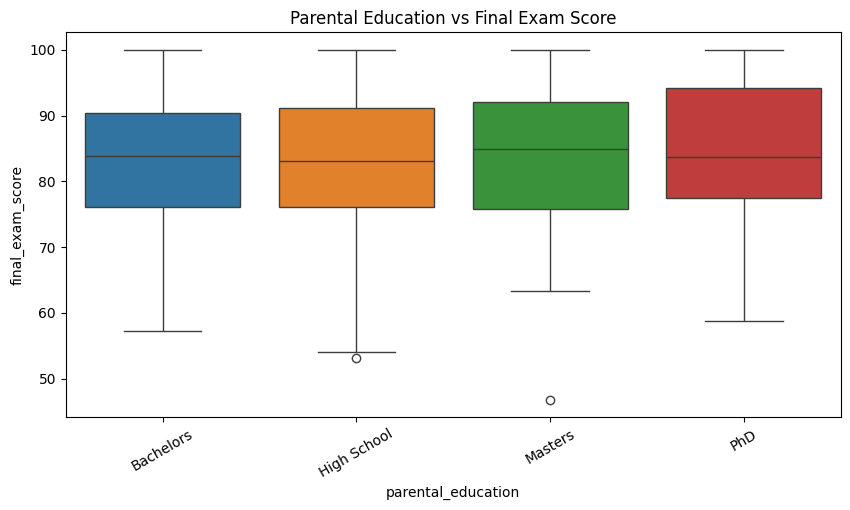

In [30]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df,
            x='parental_education',
            y='final_exam_score',
            palette='tab10')

plt.xticks(rotation=30)

plt.title("Parental Education vs Final Exam Score")

plt.show()

In [31]:
fig = px.scatter(
    df,
    x="study_time_hours",
    y="final_exam_score",
    color="final_grade",
    size="attendance_percent",
    hover_data=["gender"],
    color_discrete_sequence=px.colors.qualitative.Bold,
    title="Interactive Study Time vs Final Exam Score"
)

fig.show()

In [32]:
fig = px.histogram(
    df,
    x="final_exam_score",
    color="final_grade",
    marginal="box",
    color_discrete_sequence=px.colors.qualitative.Set2,
    title="Interactive Final Exam Score Distribution"
)

fig.show()

In [33]:
fig = px.sunburst(
    df,
    path=['gender',
          'internet_access',
          'final_grade'],
    color='final_exam_score',
    color_continuous_scale='RdYlGn',
    title="Student Performance Sunburst"
)

fig.show()

In [34]:
X = df.drop(columns=['student_id', 'final_grade'])
y = df['final_grade']

## Feature engineering

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [36]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

In [37]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', C=2, gamma='scale'))
])

In [40]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['study_time_hours', 'attendance_percent', 'sleep_hours',
       'previous_grade', 'final_exam_score'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'parental_education', 'internet_access',
       'extracurricular_activities', 'part_time_job'],
      dtype='object'))])),
                ('classifier', SVC(C=2))])

In [41]:
y_pred = model.predict(X_test)

In [42]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score : {accuracy:.2%}\n")

Accuracy Score : 89.00%



              precision    recall  f1-score   support

           A       0.93      0.91      0.92        57
           B       0.85      0.89      0.87        71
           C       0.90      0.88      0.89        52
           D       0.89      0.94      0.92        18
           F       0.00      0.00      0.00         2

    accuracy                           0.89       200
   macro avg       0.72      0.73      0.72       200
weighted avg       0.88      0.89      0.89       200



<Figure size 800x600 with 0 Axes>

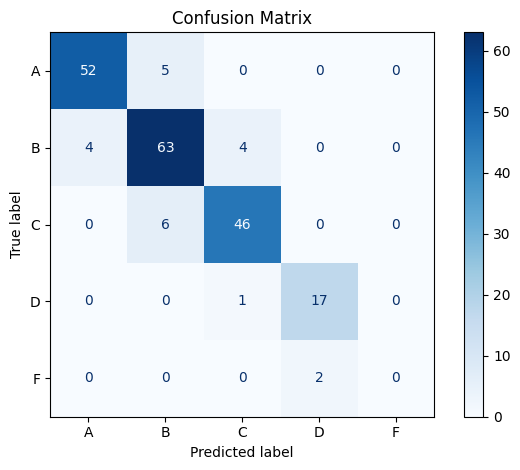

In [43]:
print(classification_report(y_test, y_pred))

fig = plt.figure(figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## Thank you..pls upvote!!!!!!!!!!!!!!